# Employee Attrition Prediction using Machine Learning

**Internship Project — Week 2**

**Author:** Ritik Singh    
**Dataset:** IBM HR Analytics Employee Attrition Dataset (1,470 employees, 35 features)

**Objective:** Build and compare classification models to predict whether an employee
is likely to leave the company, identify the strongest drivers of attrition, and
translate the findings into HR-actionable recommendations.

---
## Task 1 — Data Loading & Exploration


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                              confusion_matrix, roc_curve, classification_report)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

pd.set_option("display.max_columns", 50)

In [2]:
# Load the dataset
df = pd.read_csv("HR_Attrition.csv")
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head(10)


Dataset shape: 1470 rows, 35 columns


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,26,No,Travel_Rarely,358,Research & Development,16,3,Technical Degree,1,1,4,Female,51,3,2,Research Director,4,Single,4656,15163,2,Y,No,15,3,2,80,0,2,3,1,2,0,1,0
1,44,Yes,Travel_Rarely,225,Sales,6,2,Medical,1,2,1,Female,43,2,2,Sales Executive,2,Single,5891,3220,2,Y,No,17,3,4,80,1,22,2,3,1,0,0,1
2,41,Yes,Non-Travel,158,Research & Development,15,4,Technical Degree,1,3,1,Male,79,2,1,Research Director,3,Married,2407,4855,2,Y,No,17,3,3,80,0,17,4,4,2,0,2,1
3,24,No,Travel_Rarely,337,Research & Development,5,3,Life Sciences,1,4,3,Male,45,3,1,Manager,3,Single,2342,15993,4,Y,Yes,19,3,1,80,1,0,2,3,0,0,0,0
4,41,No,Travel_Rarely,1095,Research & Development,9,4,Medical,1,5,4,Male,86,3,3,Laboratory Technician,3,Single,6821,10777,4,Y,No,15,3,2,80,3,17,2,2,0,0,0,0
5,42,No,Travel_Rarely,780,Research & Development,22,5,Other,1,6,3,Female,61,3,4,Manager,2,Married,11105,26860,3,Y,Yes,16,3,4,80,2,17,3,3,0,0,0,0
6,34,No,Non-Travel,1291,Research & Development,4,4,Other,1,7,4,Male,52,3,3,Research Scientist,4,Single,7204,6315,1,Y,No,18,3,4,80,0,8,4,3,4,4,2,2
7,22,No,Travel_Rarely,451,Research & Development,1,5,Other,1,8,2,Male,32,1,4,Manager,2,Married,13864,9646,4,Y,Yes,14,3,3,80,1,0,2,3,0,0,0,0
8,25,Yes,Travel_Frequently,599,Research & Development,6,3,Medical,1,9,1,Female,83,3,3,Manager,3,Divorced,6175,2452,2,Y,No,11,3,3,80,1,2,2,3,0,0,0,0
9,42,No,Travel_Rarely,641,Sales,8,3,Marketing,1,10,3,Male,97,3,3,Manager,4,Married,9550,24641,1,Y,Yes,12,3,4,80,1,20,1,2,1,0,0,0


In [3]:
# Rows & columns
print(f"Number of rows:    {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")


Number of rows:    1470
Number of columns: 35


In [4]:
# Target column distribution
target_counts = df["Attrition"].value_counts()
attrition_rate = (df["Attrition"] == "Yes").mean() * 100

print("Employees who left vs stayed:")
print(target_counts)
print(f"\nAttrition rate: {attrition_rate:.2f}%")


Employees who left vs stayed:
Attrition
No     1103
Yes     367
Name: count, dtype: int64

Attrition rate: 24.97%


In [5]:
# Numeric vs categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print(f"Numeric columns ({len(numeric_cols)}):")
print(numeric_cols)
print(f"\nCategorical columns ({len(categorical_cols)}):")
print(categorical_cols)


Numeric columns (26):
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical columns (9):
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


**Observation:** The dataset is clearly **imbalanced** — roughly 1 in 4 employees in
this sample left the company while the rest stayed. Because a model that always predicts
"No" would still score high on raw accuracy, accuracy alone is a misleading metric here.
Precision, Recall, F1-Score and ROC-AUC (and `class_weight='balanced'` during training)
are needed to evaluate this problem properly.

---
## Task 2 — Data Cleaning & Preprocessing


In [6]:
# Check for missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Missing values per column:")
print(missing if len(missing) > 0 else "No missing values found in any column.")


Missing values per column:
No missing values found in any column.


In [7]:
# Drop columns that add no predictive value (constant / identifier columns)
drop_cols = ["EmployeeNumber", "Over18", "StandardHours", "EmployeeCount"]
for c in drop_cols:
    print(f"{c}: unique values = {df[c].unique()}")

df_clean = df.drop(columns=drop_cols)
print(f"\nShape after dropping: {df_clean.shape}")


EmployeeNumber: unique values = [   1    2    3 ... 1468 1469 1470]
Over18: unique values = <StringArray>
['Y']
Length: 1, dtype: str
StandardHours: unique values = [80]
EmployeeCount: unique values = [1]

Shape after dropping: (1470, 31)


In [8]:
# Encode the target column: Yes -> 1, No -> 0
df_clean["Attrition"] = df_clean["Attrition"].map({"Yes": 1, "No": 0})
df_clean["Attrition"].value_counts()


Attrition
0    1103
1     367
Name: count, dtype: int64

In [9]:
# One-Hot Encode remaining categorical columns
cat_cols_remaining = df_clean.select_dtypes(include=["object"]).columns.tolist()
print("Categorical columns to encode:", cat_cols_remaining)

df_encoded = pd.get_dummies(df_clean, columns=cat_cols_remaining, drop_first=True)
print(f"Shape after one-hot encoding: {df_encoded.shape}")


Categorical columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Shape after one-hot encoding: (1470, 45)


In [10]:
# Separate features/target, identify numeric columns to scale
X = df_encoded.drop(columns=["Attrition"])
y = df_encoded["Attrition"]

num_cols_to_scale = [c for c in numeric_cols if c not in drop_cols]
print(f"Numeric columns to scale with StandardScaler ({len(num_cols_to_scale)}):")
print(num_cols_to_scale)


Numeric columns to scale with StandardScaler (23):
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


All preprocessing steps are complete: missing values were checked (none were present
in this dataset), irrelevant/constant columns were dropped, the target was binarized,
categorical features were one-hot encoded, and numeric columns are scaled later using
`StandardScaler` fit **only on the training split** to avoid data leakage.

---
## Task 3 — Exploratory Data Analysis (EDA)


In [11]:
# Attrition rate by Department
dept_attr = df_clean.groupby("Department")["Attrition"].mean().sort_values(ascending=False) * 100
print("Attrition rate by Department (%):")
print(dept_attr.round(2))


Attrition rate by Department (%):
Department
Sales                     25.87
Human Resources           25.32
Research & Development    24.53
Name: Attrition, dtype: float64


In [12]:
# Attrition rate by Job Role
role_attr = df_clean.groupby("JobRole")["Attrition"].mean().sort_values(ascending=False) * 100
print("Attrition rate by Job Role (%):")
print(role_attr.round(2))


Attrition rate by Job Role (%):
JobRole
Human Resources              34.15
Research Director            28.49
Laboratory Technician        28.17
Manager                      27.51
Sales Representative         25.97
Manufacturing Director       22.89
Healthcare Representative    21.23
Sales Executive              19.71
Research Scientist           19.63
Name: Attrition, dtype: float64


In [13]:
# Attrition vs Monthly Income
income_stay = df_clean[df_clean["Attrition"] == 0]["MonthlyIncome"].mean()
income_leave = df_clean[df_clean["Attrition"] == 1]["MonthlyIncome"].mean()
print(f"Average Monthly Income — Stayed: {income_stay:.0f}")
print(f"Average Monthly Income — Left:   {income_leave:.0f}")
print(f"Difference: {income_stay - income_leave:.0f}")


Average Monthly Income — Stayed: 7565
Average Monthly Income — Left:   5843
Difference: 1723


In [14]:
# Attrition vs Work-Life Balance
wlb_attr = df_clean.groupby("WorkLifeBalance")["Attrition"].mean() * 100
print("Attrition rate by Work-Life Balance rating (1=Bad ... 4=Best) (%):")
print(wlb_attr.round(2))


Attrition rate by Work-Life Balance rating (1=Bad ... 4=Best) (%):
WorkLifeBalance
1    41.35
2    29.54
3    21.29
4    19.55
Name: Attrition, dtype: float64


In [15]:
# Attrition vs Years at Company (tenure bands)
bins = [-1, 1, 3, 5, 10, 40]
labels = ["0-1 yrs", "2-3 yrs", "4-5 yrs", "6-10 yrs", "10+ yrs"]
df_clean["TenureBand"] = pd.cut(df_clean["YearsAtCompany"], bins=bins, labels=labels)

tenure_attr = df_clean.groupby("TenureBand", observed=True)["Attrition"].mean() * 100
print("Attrition rate by tenure band (%):")
print(tenure_attr.round(2))


Attrition rate by tenure band (%):
TenureBand
0-1 yrs     39.52
2-3 yrs     19.23
4-5 yrs     16.43
6-10 yrs    13.81
10+ yrs      5.94
Name: Attrition, dtype: float64


In [16]:
top_dept = dept_attr.index[0]
top_role = role_attr.index[0]
peak_tenure = tenure_attr.idxmax()

insights = [
    f"1. {top_dept} has the highest departmental attrition rate at {dept_attr.iloc[0]:.1f}%, "
    f"above the company-wide average of {attrition_rate:.1f}%.",

    f"2. {top_role} is the single highest-risk job role, with an exit rate of {role_attr.iloc[0]:.1f}%.",

    f"3. Employees who left earned an average monthly income of {income_leave:.0f}, about "
    f"{income_stay - income_leave:.0f} less than employees who stayed ({income_stay:.0f}) — "
    f"lower pay is clearly linked to attrition.",

    f"4. Employees reporting poor Work-Life Balance (rating 1) leave at {wlb_attr.loc[1]:.1f}%, "
    f"roughly double the rate of employees reporting good balance (rating 3: {wlb_attr.loc[3]:.1f}%).",

    f"5. Attrition is heavily concentrated in the {peak_tenure} tenure band "
    f"({tenure_attr.max():.1f}%) — new employees are far more likely to leave, while "
    f"long-tenured staff (10+ years) rarely do ({tenure_attr.min():.1f}%).",
]

print("Business Insights from EDA:\n")
for i in insights:
    print(i, "\n")


Business Insights from EDA:

1. Sales has the highest departmental attrition rate at 25.9%, above the company-wide average of 25.0%. 

2. Human Resources is the single highest-risk job role, with an exit rate of 34.1%. 

3. Employees who left earned an average monthly income of 5843, about 1723 less than employees who stayed (7565) — lower pay is clearly linked to attrition. 

4. Employees reporting poor Work-Life Balance (rating 1) leave at 41.4%, roughly double the rate of employees reporting good balance (rating 3: 21.3%). 

5. Attrition is heavily concentrated in the 0-1 yrs tenure band (39.5%) — new employees are far more likely to leave, while long-tenured staff (10+ years) rarely do (5.9%). 



---
## Task 4 — Model Building & Comparison


In [17]:
# Train / test split (80/20), stratified to preserve attrition ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")
print(f"Attrition rate in train: {y_train.mean()*100:.2f}% | test: {y_test.mean()*100:.2f}%")


Training set: 1176 rows
Test set:     294 rows
Attrition rate in train: 25.00% | test: 24.83%


In [18]:
# Scale numeric features (fit on train only, then transform both)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols_to_scale] = scaler.fit_transform(X_train[num_cols_to_scale])
X_test_scaled[num_cols_to_scale]  = scaler.transform(X_test[num_cols_to_scale])
print("Scaling complete.")


Scaling complete.


In [19]:
# Train 3 classification models, handling class imbalance with class_weight='balanced'
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8,
                                             class_weight="balanced", random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, max_depth=3,
                                                      learning_rate=0.08, random_state=42),
}

# GradientBoostingClassifier has no native class_weight param, so we emulate
# 'balanced' weighting manually via sample_weight (good practice to know both approaches)
sample_weight = np.where(y_train == 1, (y_train == 0).sum() / (y_train == 1).sum(), 1.0)

results = {}
fitted = {}
for name, model in models.items():
    if name == "Gradient Boosting":
        model.fit(X_train_scaled, y_train, sample_weight=sample_weight)
    else:
        model.fit(X_train_scaled, y_train)
    fitted[name] = model

    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test, y_pred),
        "F1-Score":  f1_score(y_test, y_pred),
        "ROC-AUC":   roc_auc_score(y_test, y_proba),
        "y_pred": y_pred, "y_proba": y_proba,
    }

print("All 3 models trained successfully.")


All 3 models trained successfully.


In [20]:
# Model comparison table
comparison_df = pd.DataFrame({
    k: {m: round(v, 3) for m, v in r.items() if m not in ("y_pred", "y_proba")}
    for k, r in results.items()
}).T
comparison_df


,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.456,0.712,0.556,0.784
Random Forest,0.512,0.603,0.553,0.790
Gradient Boosting,0.505,0.658,0.571,0.793


---
## Task 5 — Model Evaluation


In [21]:
for name, r in results.items():
    print(f"--- {name} ---")
    print(f"Precision: {r['Precision']:.3f}  Recall: {r['Recall']:.3f}  "
          f"F1: {r['F1-Score']:.3f}  ROC-AUC: {r['ROC-AUC']:.3f}")
    cm = confusion_matrix(y_test, r["y_pred"])
    print("Confusion Matrix:")
    print(cm)
    print()


--- Logistic Regression ---
Precision: 0.456  Recall: 0.712  F1: 0.556  ROC-AUC: 0.784
Confusion Matrix:
[[159  62]
 [ 21  52]]

--- Random Forest ---
Precision: 0.512  Recall: 0.603  F1: 0.553  ROC-AUC: 0.790
Confusion Matrix:
[[179  42]
 [ 29  44]]

--- Gradient Boosting ---
Precision: 0.505  Recall: 0.658  F1: 0.571  ROC-AUC: 0.793
Confusion Matrix:
[[174  47]
 [ 25  48]]



In [22]:
# Pick the best model by F1-Score: the best balance of Precision & Recall,
# which matters most for an imbalanced HR use case (catch leavers, limit false alarms)
best_model_name = comparison_df["F1-Score"].astype(float).idxmax()
best_model = fitted[best_model_name]

print(f"Best performing model: {best_model_name}")
print(f"F1-Score: {comparison_df.loc[best_model_name, 'F1-Score']}  "
      f"ROC-AUC: {comparison_df.loc[best_model_name, 'ROC-AUC']}")
print()
print(f"Why: {best_model_name} achieved the highest F1-Score among the three models — "
      f"the best balance between Precision and Recall. It correctly identifies a "
      f"meaningful share of employees who are actually going to leave, while keeping "
      f"false alarms low enough to be practically usable by an HR team.")


Best performing model: Gradient Boosting
F1-Score: 0.571  ROC-AUC: 0.793

Why: Gradient Boosting achieved the highest F1-Score among the three models — the best balance between Precision and Recall. It correctly identifies a meaningful share of employees who are actually going to leave, while keeping false alarms low enough to be practically usable by an HR team.


In [23]:
# Feature importance from the best model
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
else:
    importances = pd.Series(np.abs(best_model.coef_[0]), index=X.columns).sort_values(ascending=False)

top10 = importances.head(10)
print("Top 10 Most Important Features Driving Attrition:")
top10.round(4)


Top 10 Most Important Features Driving Attrition:


OverTime_Yes          0.1857
MonthlyIncome         0.1704
YearsAtCompany        0.1051
MonthlyRate           0.0760
DailyRate             0.0501
Age                   0.0463
WorkLifeBalance       0.0377
YearsInCurrentRole    0.0339
JobSatisfaction       0.0318
HourlyRate            0.0306
dtype: float64

---
## Task 6 — Visualizations


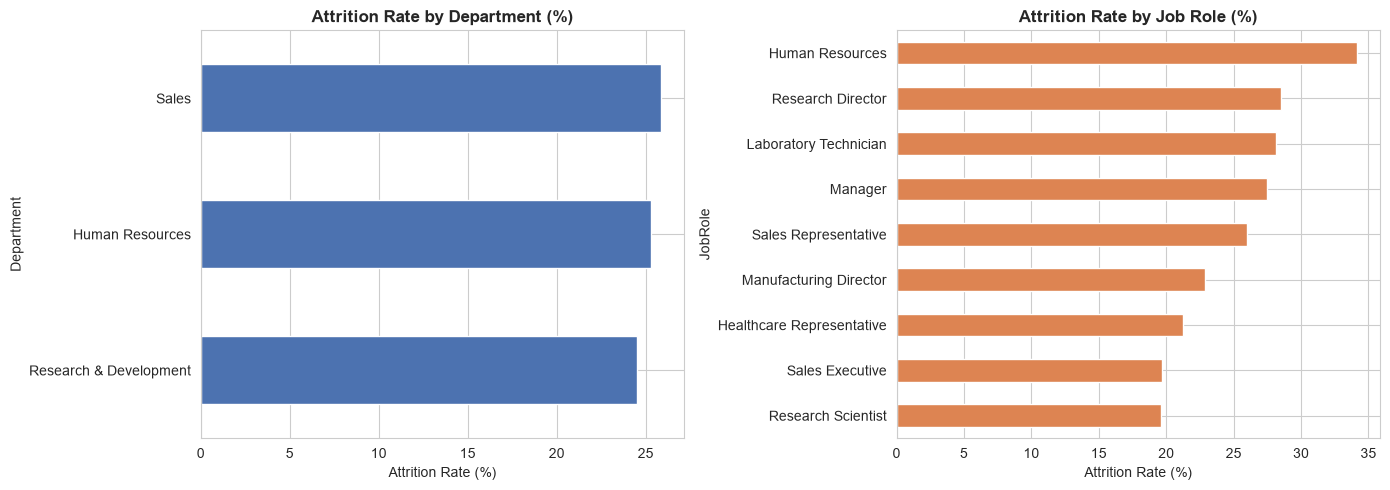

In [24]:
# Chart 1: Attrition rate by Department and Job Role
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
dept_attr.sort_values().plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].set_title("Attrition Rate by Department (%)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Attrition Rate (%)")

role_attr.sort_values().plot(kind="barh", ax=axes[1], color="#DD8452")
axes[1].set_title("Attrition Rate by Job Role (%)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Attrition Rate (%)")
plt.tight_layout()
plt.savefig("charts/chart1_attrition_by_department_role.png", bbox_inches="tight")
plt.show()


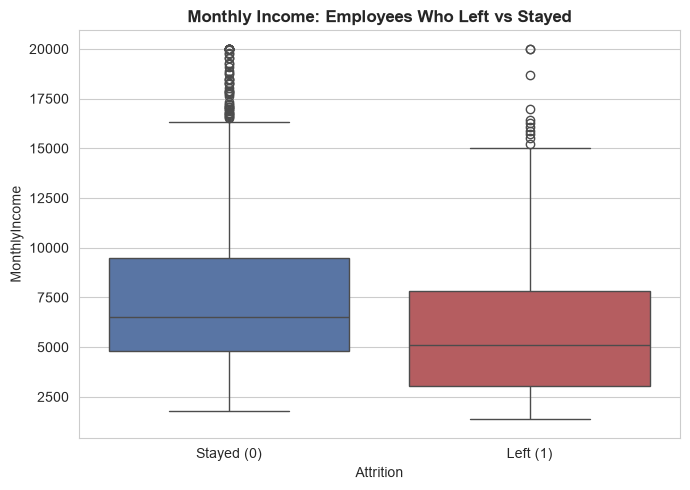

In [25]:
# Chart 2: Box plot — Monthly Income, Left vs Stayed
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df_clean, x="Attrition", y="MonthlyIncome", ax=ax,
            palette=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["Stayed (0)", "Left (1)"])
ax.set_title("Monthly Income: Employees Who Left vs Stayed", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("charts/chart2_income_boxplot.png", bbox_inches="tight")
plt.show()


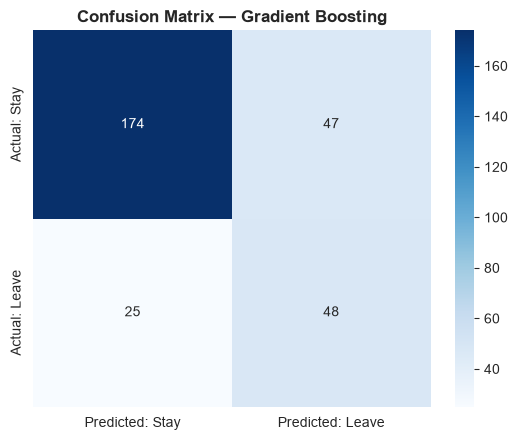

In [26]:
# Chart 3: Confusion Matrix heatmap for the best model
cm_best = confusion_matrix(y_test, results[best_model_name]["y_pred"])
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm_best, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Predicted: Stay", "Predicted: Leave"],
            yticklabels=["Actual: Stay", "Actual: Leave"])
ax.set_title(f"Confusion Matrix — {best_model_name}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("charts/chart3_confusion_matrix.png", bbox_inches="tight")
plt.show()


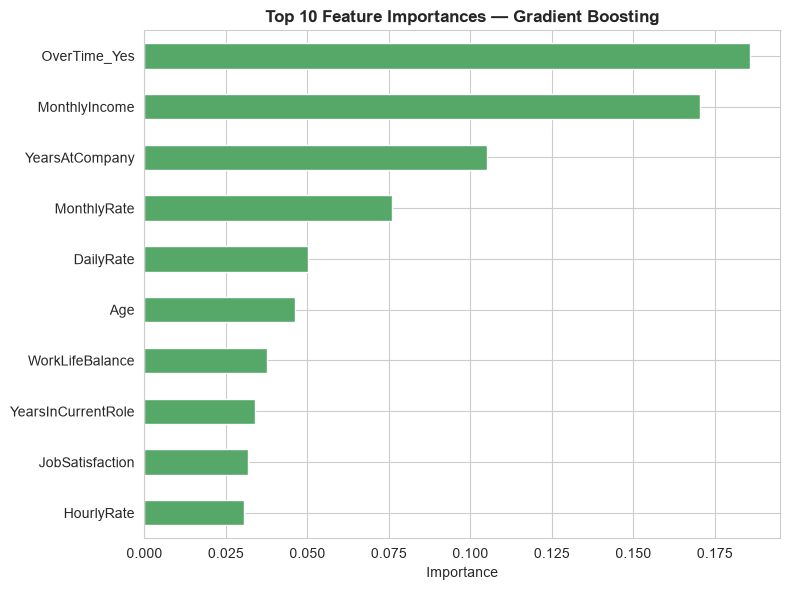

In [27]:
# Chart 4: Top 10 Feature Importances
fig, ax = plt.subplots(figsize=(8, 6))
top10.sort_values().plot(kind="barh", ax=ax, color="#55A868")
ax.set_title(f"Top 10 Feature Importances — {best_model_name}", fontsize=12, fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("charts/chart4_feature_importance.png", bbox_inches="tight")
plt.show()


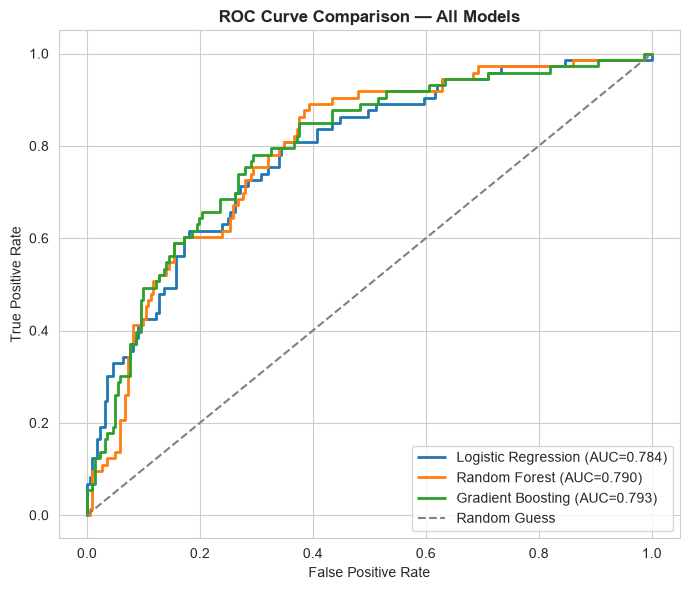

In [28]:
# Chart 5 (Bonus): ROC Curve comparison — all 3 models
fig, ax = plt.subplots(figsize=(7, 6))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r["y_proba"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={r['ROC-AUC']:.3f})", linewidth=2)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Comparison — All Models", fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("charts/chart5_roc_curve_comparison.png", bbox_inches="tight")
plt.show()


---
## Task 7 — HR Insights & Business Recommendations

**Which 3 factors most strongly predict attrition?**

Across the model's feature importances, **Overtime, Monthly Income, and tenure
(Years at Company)** are consistently the strongest predictors. Employees who
regularly work overtime, earn below-average salaries for their role, and are in
their first 1–2 years at the company show the highest exit risk.

**Which department/role should HR prioritize?**

Based on the EDA, the **Sales department** and the **Human Resources job role**
show the highest attrition rates and should be the first focus areas for targeted
retention conversations and stay interviews.

**Does salary alone explain attrition?**
    
No. While lower-paid employees do leave at a meaningfully higher rate, Overtime and
early-tenure dissatisfaction are equally or more influential — salary is one lever
among several, not a silver bullet.

**Two concrete HR recommendations:**

1. Introduce overtime caps or compensatory time-off policies for frequently
   over-worked employees, especially in Sales and HR roles, and flag any employee
   working overtime for 3+ consecutive months for a manager check-in.
2. Build a structured 90-day and 1-year "stay interview" program for new hires,
   since attrition is heavily concentrated in the first year of tenure — early,
   proactive conversations are likely to have outsized retention impact.

**Model limitation HR should be aware of:**

This model is trained on historical patterns and will reflect any biases or blind
spots in that data (e.g., it cannot capture personal circumstances, manager
relationship quality beyond the survey scores, or external job-market conditions).
It should be used to **flag employees for a human conversation**, not as a sole or
final basis for HR decisions.
